# EX3: Guided Microwave Propagation

The purpose of this lab is to develop experimental techniques to generate microwaves and observe how they propagate in rectangular waveguides. Microwaves typically operate in the 2.45 GHz frequency range.

### 1. Finding ratio $\eta$

For any electromagnetic wave in free space, we know that we can relate the $E$ field to the magnetic flux density $B$ field by $c$ (speed of light) and the $H$ field by $\mu_0$ (permeability of free space):

\begin{align}
E &= cB \tag{1.1} \\
H &= \frac{B}{\mu_{0}} \tag{1.2} \\
\end{align}

where $c = 3 \times 10^8$ m/s and $\mu_0 = 4\pi \times 10^{-7}$ N/A^2.

Plugging this back into the formula for $\eta$, we get:

\begin{align*}
\eta &= \frac{E}{H} \\
\eta &= \frac{cB}{\frac{B}{\mu_{0}}} \\
&= c\mu_{0} \\
&= \boxed{377 \Omega} \tag{1.3} \\ 
\end{align*}




### 2. E-field reflection coefficient

At the interface between two regions, we know there are 3 different E-fields:

\begin{align}
E_i &= E_o \tag{2.1} \\
E_r &= \rho E_o \tag{2.2} \\
E_t &= \tau E_o \tag{2.3} 
\end{align}

where $E_i$ = incident field, $E_r$ = reflected field, $E_t$ = transmitted field.

From here, we can apply boundary conditions at the interface to find the reflection $\rho$ and transmission $\tau$ coefficients. We assume the incident plane wave is striking the interface at 90 deg, so the E-fields have no normal components.

a. Continuity of tangential electric field:
\begin{align*}
E_i + E_r &= E_t \\
E_o + \rho E_o &= \tau E_o \\
1 + \rho &= \tau \tag{2.4} 
\end{align*}

b. Continuity of tangential magnetic field (note: if $\eta_1 < \eta_2$, the reflected H-field will undergo a 180 deg phase shift):
\begin{align*}
H_i - H_r &= H_t \\
\frac{E_i}{\eta_1} - \frac{E_r}{\eta_1} &= \frac{E_t}{\eta_2} \\
\frac{E_o}{\eta_1} - \frac{\rho E_o}{\eta_1} &= \frac{\tau E_o}{\eta_2} \\
\frac{1 - \rho}{\eta_1} &= \frac{\tau}{\eta_2} \tag{2.5}
\end{align*}

Solving this system of two equations ($2.4$ and $2.5$), we get an expression for both $\rho$ and $\tau$:

\begin{align*}
\frac{1 - \rho}{\eta_1} &= \frac{1 + \rho}{\eta_2} \\
\eta_2 - \eta_2 \rho &= \eta_1 + \eta_1 \rho\\
\rho &= \boxed{\frac{\eta_2 - \eta_1}{\eta_2 + \eta_1}} \tag{2.6} \\ \\ 
\end{align*}

\begin{align*}
\frac{1 - (\tau - 1)}{\eta_1} &= \frac{\tau}{\eta_2} \\
2\eta_2 - \tau \eta_2 &= \tau \eta_1 \\
\tau &= \boxed{\frac{2 \eta_2}{\eta_1 + \eta_2}} \tag{2.7}
\end{align*}



### 3. Plotting Smith charts

What is it? Smitch chart is a graphing tool used in radio freq engineering to "analyze and design impedance-maching circuits, transmission lines, and antennas" - Google. It's a polar plot that visualizes/maps reflection and transmission coefficients.  


In [21]:
import numpy as np
import matplotlib.pyplot as plt

#### 3.1 Fixed resistance

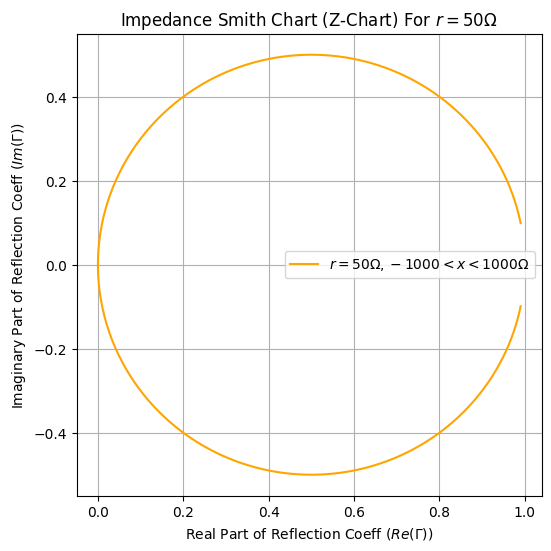

In [22]:
z_0 = 50        # Charateristic waveguide impedance 
r = 50          # Re(z) where z = genral complex impedance
x_min = -1000
x_max = 1000

z = r + 1j * np.linspace(x_min, x_max, 2000)
gamma = (z - z_0) / (z + z_0)     # Complex reflection coefficients

plt.figure(figsize=(6, 6))
plt.plot(gamma.real, gamma.imag, label=r"$r = 50 \Omega, -1000 < x < 1000 \Omega$", color='orange')
plt.xlabel(r"Real Part of Reflection Coeff ($Re(\Gamma)$)")
plt.ylabel(r"Imaginary Part of Reflection Coeff ($Im(\Gamma)$)")
plt.title(r"Impedance Smith Chart (Z-Chart) For $r = 50 \Omega$")
plt.legend()
plt.grid()
plt.show()


This is what the Smith chart looks like for $r = 50 \Omega$. Some observations:

- Plot forms a perfect circle that's nearly complete - missing segment occurs arounnd $(1, 0)$
- Plot passes through origin ($\Gamma = 0$) when $z = z_0$

#### 3.2 Multiple resistances

/var/folders/gs/fb4_4gh57jq_80swpg0lssk00000gn/T/ipykernel_8291/1357739567.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


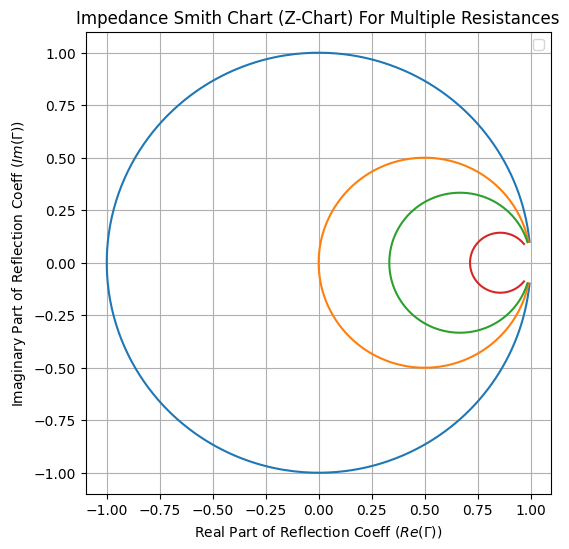

In [23]:
def smith_chart_multiple_r():
    z_0 = 50                # Charateristic waveguide impedance 
    r = [0, 50, 100, 300]   # Resistance
    x_min = -1000
    x_max = 1000

    for r_i in r:
        z = r_i + 1j * np.linspace(x_min, x_max, 2000)
        gamma = (z - z_0) / (z + z_0)     
        plt.plot(gamma.real, gamma.imag)

plt.figure(figsize=(6, 6))
smith_chart_multiple_r()
plt.xlabel(r"Real Part of Reflection Coeff ($Re(\Gamma)$)")
plt.ylabel(r"Imaginary Part of Reflection Coeff ($Im(\Gamma)$)")
plt.title(r"Impedance Smith Chart (Z-Chart) For Multiple Resistances")
plt.legend()
plt.grid()
plt.show()

This is what the Smith chart looks like for multiple $r$ values. Some observations:

- Circles get smaller as $r$ increases with centers moving further to the right
- $r = 0 \Omega$ gives us a unit circle centered around the origin
- The unit circle here means $|\Gamma| = 1$, which means we get input fields are 100% reflected 
- ^ This makes sense since $r = 0$ which means no energy is dissipated as heat, load is likely made up of only inductors and capacitors

#### 3.3 Fixed reactance

/var/folders/gs/fb4_4gh57jq_80swpg0lssk00000gn/T/ipykernel_8291/3827059674.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


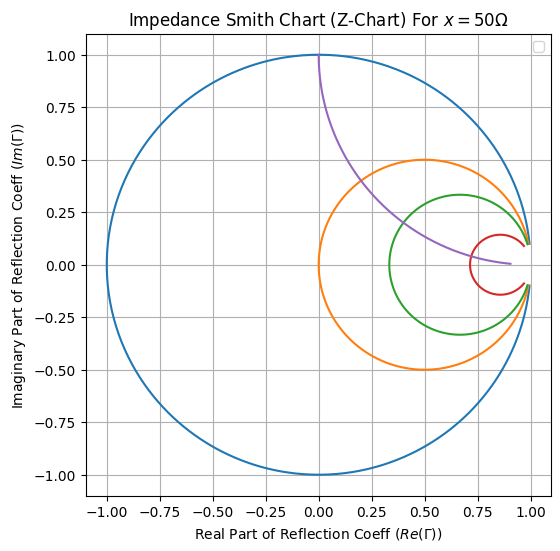

In [24]:
def smith_chart_fixed_x():
    x = 50 
    z = np.linspace(0, 1000, 1000) + 1j * x
    gamma = (z - z_0) / (z + z_0)     
    plt.plot(gamma.real, gamma.imag)

plt.figure(figsize=(6, 6))
smith_chart_multiple_r()
smith_chart_fixed_x()
plt.xlabel(r"Real Part of Reflection Coeff ($Re(\Gamma)$)")
plt.ylabel(r"Imaginary Part of Reflection Coeff ($Im(\Gamma)$)")
plt.title(r"Impedance Smith Chart (Z-Chart) For $x = 50 \Omega$")
plt.legend()
plt.grid()
plt.show()

This is what the Smith chart looks like for $x = 50 \Omega$ (purple line). Some observations:

- The purple curve isn't concentric like the other circles
- In fact, it actually intersects the fixed resistance circles at $90 \degree$ angles

#### 3.4 Multiple reactances


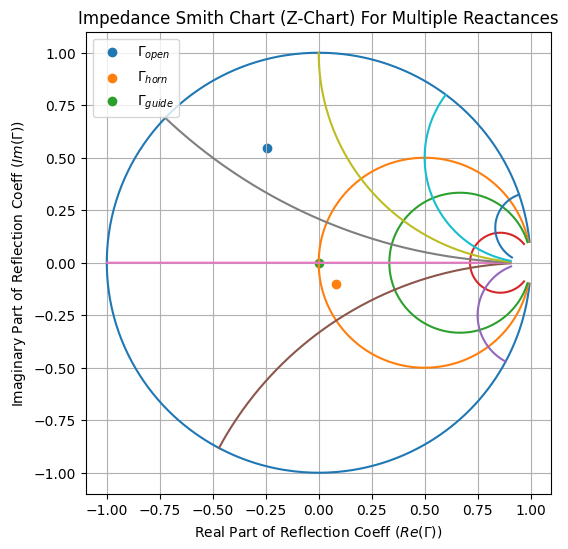

In [36]:

def smith_chart_multiple_x():
    x = [-200, -30, 0, 20, 50, 100, 300] 
    for x_i in x:
        z = np.linspace(0, 1000, 1500) + 1j * x_i
        gamma = (z - z_0) / (z + z_0)     
        plt.plot(gamma.real, gamma.imag)

plt.figure(figsize=(6, 6))
smith_chart_multiple_r()
smith_chart_multiple_x()
plt.xlabel(r"Real Part of Reflection Coeff ($Re(\Gamma)$)")
plt.ylabel(r"Imaginary Part of Reflection Coeff ($Im(\Gamma)$)")
plt.title(r"Impedance Smith Chart (Z-Chart) For Multiple Reactances")

# Your normalized impedances
z1 = 0.349 + 0.592j
z2 = 1.154 - 0.234j
z3 = 1 - 0j

# Convert to Reflection Coefficients (Gamma)
gamma1 = (z1 - 1) / (z1 + 1)
gamma2 = (z2 - 1) / (z2 + 1)
gamma3 = (z3 - 1) / (z3 + 1)

# Plot the points (magnitude and angle in radians)
plt.scatter(gamma1.real, gamma1.imag, label=r"$\Gamma_{open}$")
plt.scatter(gamma2.real, gamma2.imag, label=r"$\Gamma_{horn}$")
plt.scatter(gamma3.real, gamma3.imag, label=r"$\Gamma_{guide}$")
plt.legend()

plt.grid()
plt.show()


This is what the Smith chart looks like for multiple $x$ values. Some observations:

- These new fixed $x$ curves are only part-circles since we don't let $r$ drop below $0$ (we assume no negative resistances)
- Seem like positive $x$ values create inductive curves in the top half of the imaginary plane since $V_L$ leads $V_o$
- ^ Negative $x$ values form capactive curves in bottom half since $V_c$ lags $V_o$